# Notebook 04 — Per-Device Event-Conditioned Reliability Analysis

**Motivation.** Notebooks 02–03 analysed all six end devices pooled together for every event comparison (E1–E8). The supervisor asked for the analysis to be repeated **per device**, rather than only as a deployment-wide sum, so that pooled findings can be checked for whether they hold uniformly across devices or are driven by a subset of them.

**What this notebook does NOT do.** It does not redefine or recompute any event thresholds. See the note in Section 1 for why.

**What this notebook adds.** For every event, PDR$_{\text{link}}$, sample size, and (where applicable) the Mann–Whitney/rank-biserial comparison are recomputed **within each device separately**, then compared against the pooled result from Notebook 03. A single consistency table and figure at the end summarise whether each pooled effect direction replicates across all six devices.

## 0 · Imports & Load

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
# TODO CAN WE HAVE THE ASSET THING HERE?
DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset -- outage intervals excluded only (same convention as Notebook 03)
df_link = df[~df['is_outage']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} \u2192 {df["time"].max().date()}')

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.titlesize': 13,
    'axes.labelsize': 13, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255', 'teal': '#44AA99', 'yellow': '#DDCC77'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
FIG_DIR = Path('../figures/4')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    # fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/4/{name}')
    plt.show()


def pdr_grp(grp):
    rx = len(grp)
    lost = int(grp['tx_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


print('Style ready.')

Style ready.


## 1 · Do the Event Thresholds Need to Be Recomputed Per Device?

**No.** Every event threshold is grounded in something external to this specific deployment: a WHO exposure guideline (E4), a sensor-noise repeatability bound (E2), an ASHRAE comfort band (E6), a fixed signal-quality scale (E8), a calendar definition (E3), or a deployment-wide distributional split reported as such in the methodology (E1, E5). Recomputing any of these per device would silently change what the event *means*: "high CO\u2082" would stop being a comparable occupancy state across rooms and instead become "high relative to this room's own typical range", which conflates the event with the room's baseline ventilation and occupancy profile, and breaks comparability with the absolute health/regulatory thresholds cited in the methodology.

**What changes in this notebook is therefore not the event definitions, but how the outcome is reported.** For every event, PDR$_{\text{link}}$ (and, where the group sizes allow it, the comparison test) is recomputed separately **within each device**, using the exact same category boundaries as Notebook 03. This directly tests whether a pooled effect (e.g. "CO\u2082-rising intervals collapse PDR sharply") is a building-wide phenomenon or concentrated in specific rooms — which matters directly for the collision-dominated / shared-mechanism interpretation argued in Chapter 7.

In [3]:
# Device reference table -- distance comes directly from the data;
# room labels are the same descriptive labels used for figures in Notebook 02
# (not a column in the dataset, included here only for readability).
ROOM_LABELS = {
    'ED0': 'Hardware', 'ED1': 'Lab', 'ED2': 'Office',
    'ED3': 'Office', 'ED4': 'Server Room', 'ED5': 'Kitchen',
}

device_ref = (
    df.groupby('device_id')['distance'].first()
    .reset_index()
    .rename(columns={'distance': 'distance_m'})
)
device_ref['room'] = device_ref['device_id'].map(ROOM_LABELS)
device_ref = device_ref.sort_values('device_id').reset_index(drop=True)
print(device_ref.to_string(index=False))

device_id  distance_m     room
      ED0          10 Hardware
      ED1           8      Lab


## 2 · Per-Device Analysis Framework

In [4]:
def per_device_pdr_table(event_col, categories=None):
    """
    PDR_link and n for every (device, event-category) combination.
    Returns (long_df, wide_pdr, wide_n); wide_* are device x category pivots.
    """
    devices = sorted(df_link['device_id'].unique())
    if categories is None:
        categories = sorted(df_link[event_col].dropna().unique())

    rows = []
    for dev in devices:
        g_dev = df_link[df_link['device_id'] == dev]
        for cat in categories:
            g = g_dev[g_dev[event_col] == cat]
            n = len(g)
            pdr = pdr_grp(g) if n > 0 else np.nan
            rows.append({'device_id': dev, 'category': cat, 'n': n, 'pdr': pdr})

    long_df = pd.DataFrame(rows)
    wide_pdr = long_df.pivot(index='device_id', columns='category', values='pdr')[categories]
    wide_n = long_df.pivot(index='device_id', columns='category', values='n')[categories]
    return long_df, wide_pdr, wide_n


def per_device_binary_compare(event_col, group1, group0=None, min_n=5):
    """
    Per-device Mann-Whitney PDR comparison, mirroring Notebook 03's pdr_compare
    but computed separately within each device. Devices with fewer than min_n
    rows in either group are flagged rather than tested.
    """
    devices = sorted(df_link['device_id'].unique())
    rows = []
    for dev in devices:
        g_dev = df_link[df_link['device_id'] == dev]
        g1 = g_dev[g_dev[event_col] == group1]
        g0 = g_dev[g_dev[event_col] != group1] if group0 is None else g_dev[g_dev[event_col] == group0]
        n1, n0 = len(g1), len(g0)

        if n1 < min_n or n0 < min_n:
            rows.append({'device_id': dev, 'n1': n1, 'n0': n0,
                         'pdr1': pdr_grp(g1) if n1 > 0 else np.nan,
                         'pdr0': pdr_grp(g0) if n0 > 0 else np.nan,
                         'diff_pp': np.nan, 'p_value': np.nan,
                         'effect_r': np.nan, 'significant': False,
                         'note': 'insufficient n'})
            continue

        pdr1, pdr0 = pdr_grp(g1), pdr_grp(g0)
        stat, p = stats.mannwhitneyu(g1['t_radio'].values, g0['t_radio'].values,
                                      alternative='two-sided')
        r = 1 - 2 * stat / (n1 * n0)
        rows.append({'device_id': dev, 'n1': n1, 'n0': n0,
                     'pdr1': pdr1, 'pdr0': pdr0,
                     'diff_pp': pdr1 - pdr0, 'p_value': p,
                     'effect_r': r, 'significant': p < 0.05, 'note': ''})
    return pd.DataFrame(rows)


def plot_device_grouped_bar(wide_pdr, title, ylabel='PDR_link (%)', colors=None,
                             fname=None, figsize=(11, 5)):
    """Grouped bar chart: one group of bars per device, one bar per category."""
    devices = wide_pdr.index.tolist()
    categories = wide_pdr.columns.tolist()
    n_cat = len(categories)
    if colors is None:
        palette = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
        colors = palette[:n_cat]

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(devices)) * 0.85
    total_width = 0.7
    w = total_width / n_cat

    for j, cat in enumerate(categories):
        offset = (j - (n_cat - 1) / 2) * w
        vals = wide_pdr[cat].values
        bars = ax.bar(x + offset, vals, w, color=colors[j % len(colors)],
                      alpha=0.88, edgecolor='white', label=str(cat))
        for xi, v in zip(x + offset, vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
    ax.margins(x=0.04)
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, ncol=min(n_cat, 4))

    fig.tight_layout()
    if fname:
        save_fig(fig, fname)
    return fig, ax


def plot_device_heatmap(wide_pdr, title, fname=None, figsize=(9, 4.5), cmap='RdYlGn'):
    """Device x category heatmap -- used for E9 (6 SF categories x 6 devices)."""
    fig, ax = plt.subplots(figsize=figsize)
    data = wide_pdr.values.astype(float)
    vmin = np.nanmin(data) - 2
    vmax = np.nanmax(data) + 2
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(wide_pdr.columns)))
    ax.set_xticklabels(wide_pdr.columns, fontsize=12, fontweight='bold')
    ax.set_yticks(range(len(wide_pdr.index)))
    ax.set_yticklabels(wide_pdr.index, fontsize=12, fontweight='bold')

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='black')

    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('PDR_link (%)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    if fname:
        save_fig(fig, fname)
    return fig, ax


print('Per-device framework ready.')

Per-device framework ready.


## 3 · CO₂ Tier per Device (E1)

In [5]:
print('=' * 60)
print('E1: CO2 Tier PDR, per device')
print('=' * 60)
long_e1, wide_e1_pdr, wide_e1_n = per_device_pdr_table(
    'e1_co2_tier', ['background', 'moderate', 'high'])
print(wide_e1_pdr.round(2))
print('\nn per cell:')
print(wide_e1_n)

E1: CO2 Tier PDR, per device
category   background  moderate   high
device_id                             
ED0             98.36     97.78  95.90
ED1             97.42     96.80  94.21

n per cell:
category   background  moderate   high
device_id                             
ED0            252792    133997  53297
ED1            165098    110530  34105


  Saved: figures/4/04_a1_co2_tier_pdr_per_device


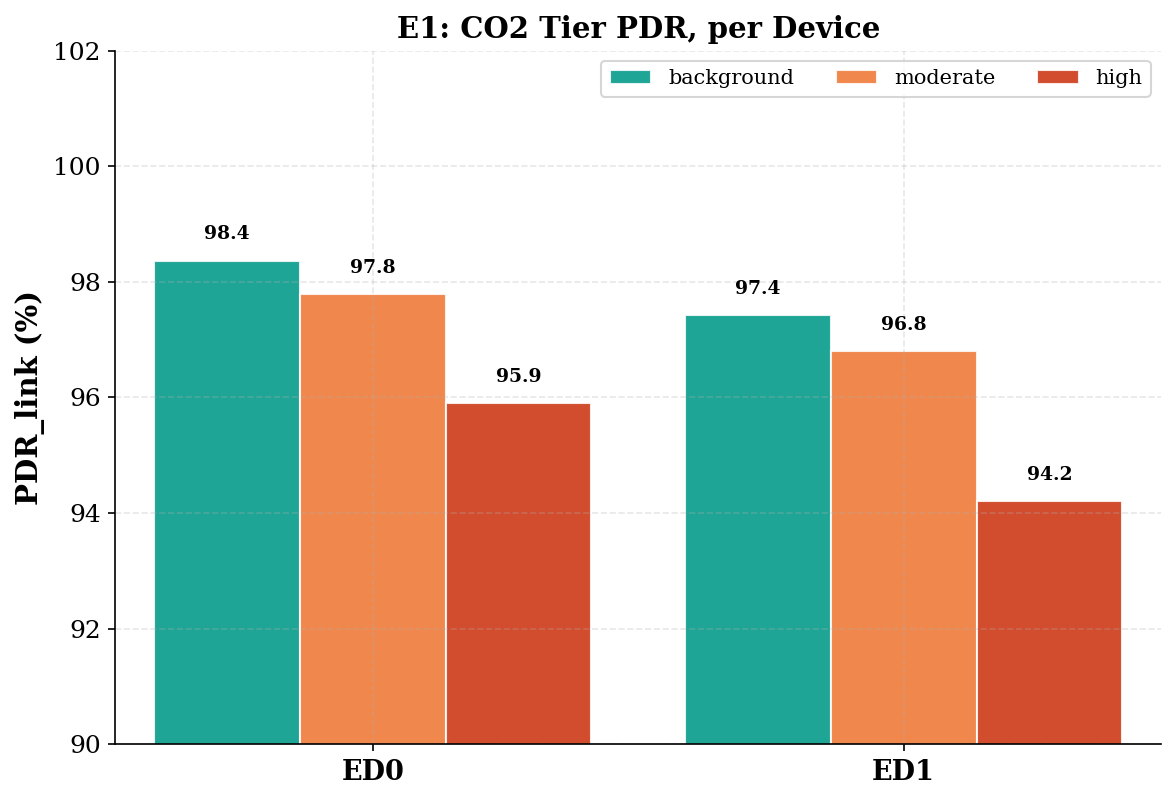

In [6]:
# Fig 04-A1 -- E1 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices = wide_e1_pdr.index.tolist()
cats1 = wide_e1_pdr.columns.tolist()
x0 = np.arange(len(devices)) * 0.85
w0 = 0.7 / len(cats1)
colors1 = [C['green'], C['orange'], C['red']]
for j, cat in enumerate(cats1):
    offset = (j - (len(cats1) - 1) / 2) * w0
    vals = wide_e1_pdr[cat].values
    ax.bar(x0 + offset, vals, w0, color=colors1[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x0 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E1: CO2 Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_a1_co2_tier_pdr_per_device')

## 4 · CO₂ Rising per Device (E2)

In [7]:
print('=' * 60)
print('E2: CO2 Rising vs Stable PDR, per device')
print('=' * 60)
e2_dev = per_device_binary_compare('e2_co2_rising', 1, 0)
print(e2_dev.to_string(index=False))

E2: CO2 Rising vs Stable PDR, per device
device_id  n1     n0      pdr1      pdr0    diff_pp  p_value  effect_r  significant note
      ED0 892 439194 62.290503 97.996095 -35.705592      0.0 -0.237457         True     
      ED1 941 308792 67.746580 96.962618 -29.216037      0.0 -0.252283         True     


  Saved: figures/4/04_a2_co2_rising_pdr_per_device


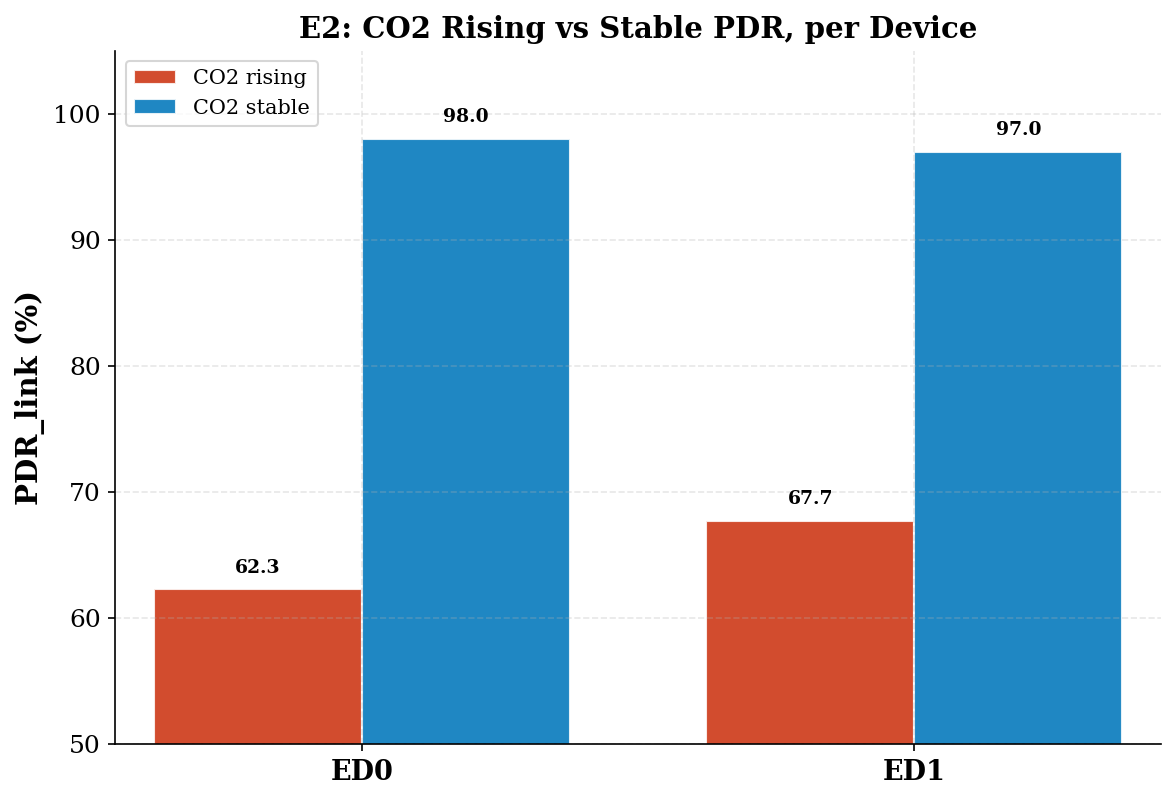

In [8]:
# Fig 04-A2 -- E2 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices = e2_dev['device_id'].tolist()
x1 = np.arange(len(devices)) * 0.85
w1 = 0.32
b1 = ax.bar(x1 - w1 / 2, e2_dev['pdr1'], w1, color=C['red'], alpha=0.88,
            edgecolor='white', label='CO2 rising')
b2 = ax.bar(x1 + w1 / 2, e2_dev['pdr0'], w1, color=C['blue'], alpha=0.88,
            edgecolor='white', label='CO2 stable')
for bar, v in zip(b1, e2_dev['pdr1']):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, e2_dev['pdr0']):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x1)
ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10)
ax.set_title('E2: CO2 Rising vs Stable PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(50, 105)

fig.tight_layout()
save_fig(fig, '04_a2_co2_rising_pdr_per_device')

## 5 · Office Hours per Device (E3)

In [9]:
print('=' * 60)
print('E3: Office Hours vs Off-Peak PDR, per device')
print('=' * 60)
e3_dev = per_device_binary_compare('e3_office_hours', 1, 0)
print(e3_dev.to_string(index=False))

E3: Office Hours vs Off-Peak PDR, per device
device_id     n1     n0      pdr1      pdr0   diff_pp       p_value  effect_r  significant note
      ED0 128127 311959 96.967472 98.263159 -1.295687 6.412534e-123 -0.010145         True     
      ED1  90591 219142 96.041346 97.167992 -1.126645  6.796428e-43 -0.008632         True     


  Saved: figures/4/04_b_office_hours_pdr_per_device


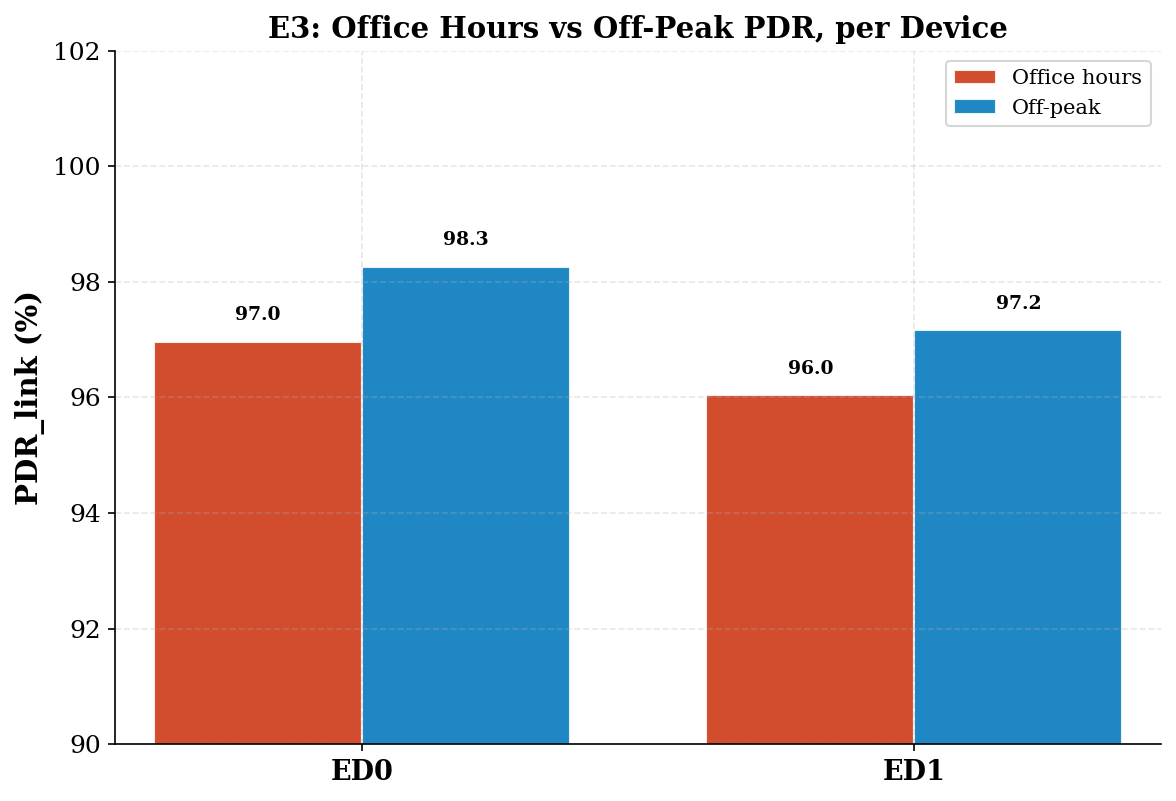

In [10]:
# Fig 04-B -- E3 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices = e3_dev['device_id'].tolist()
x0 = np.arange(len(devices)) * 0.85
w0 = 0.32
b1 = ax.bar(x0 - w0 / 2, e3_dev['pdr1'], w0, color=C['red'], alpha=0.88,
            edgecolor='white', label='Office hours')
b2 = ax.bar(x0 + w0 / 2, e3_dev['pdr0'], w0, color=C['blue'], alpha=0.88,
            edgecolor='white', label='Off-peak')
for bar, v in zip(b1, e3_dev['pdr1']):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, e3_dev['pdr0']):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10)
ax.set_title('E3: Office Hours vs Off-Peak PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_b_office_hours_pdr_per_device')

## 6 · PM2.5 Tier per Device (E4)

In [11]:
print('=' * 60)
print('E4: PM2.5 Absolute Tier PDR, per device')
print('=' * 60)
long_e4, wide_e4_pdr, wide_e4_n = per_device_pdr_table(
    'e4_pm25_tier', ['clean', 'moderate', 'elevated'])
print('PDR_link (%):')
print(wide_e4_pdr.round(2))
print('\nn per cell (note how sparse "elevated" is outside ED5):')
print(wide_e4_n)

E4: PM2.5 Absolute Tier PDR, per device
PDR_link (%):
category   clean  moderate  elevated
device_id                           
ED0        98.27     95.15     74.38
ED1        97.30     92.69     81.16

n per cell (note how sparse "elevated" is outside ED5):
category    clean  moderate  elevated
device_id                            
ED0        402989     35294      1803
ED1        282305     26687       741


  Saved: figures/4/04_c_pm25_tier_pdr_per_device


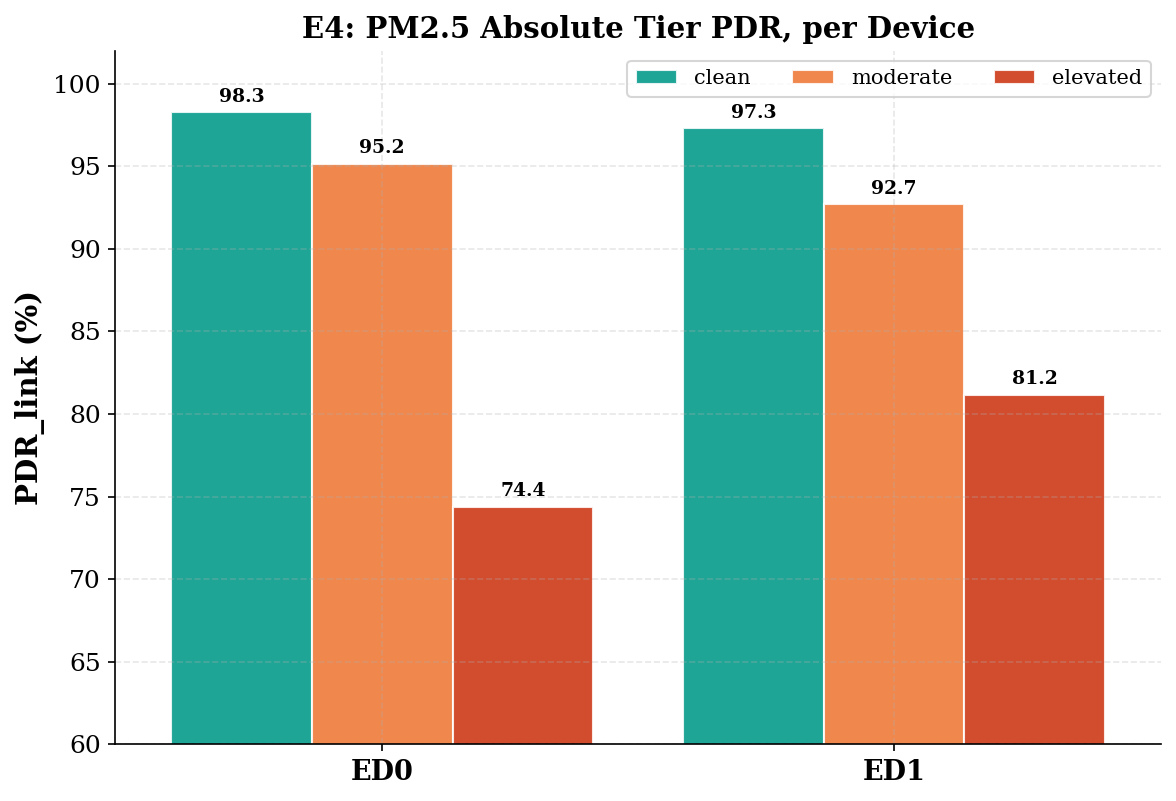

In [12]:
# Fig 04-C -- E4 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices4 = wide_e4_pdr.index.tolist()
cats4 = wide_e4_pdr.columns.tolist()
x0 = np.arange(len(devices4)) * 0.85
w0 = 0.7 / len(cats4)
colors4 = [C['green'], C['orange'], C['red']]
for j, cat in enumerate(cats4):
    offset = (j - (len(cats4) - 1) / 2) * w0
    vals = wide_e4_pdr[cat].values
    ax.bar(x0 + offset, vals, w0, color=colors4[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x0 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.4, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices4, fontsize=13, fontweight='bold')
ax.margins(x=0.06)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E4: PM2.5 Absolute Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(60, 102)

fig.tight_layout()
save_fig(fig, '04_c_pm25_tier_pdr_per_device')

## 7 · Temperature Tier per Device (E5)

In [13]:
print('=' * 60)
print('E5: Temperature Tier PDR, per device')
print('=' * 60)
long_e5, wide_e5_pdr, wide_e5_n = per_device_pdr_table(
    'e5_temp_tier', ['cool', 'moderate', 'warm'])
print(wide_e5_pdr.round(2))

E5: Temperature Tier PDR, per device
category    cool  moderate   warm
device_id                        
ED0        97.76     97.84  98.08
ED1        96.64     96.72  97.49


  Saved: figures/4/04_d1_temperature_tier_pdr_per_device


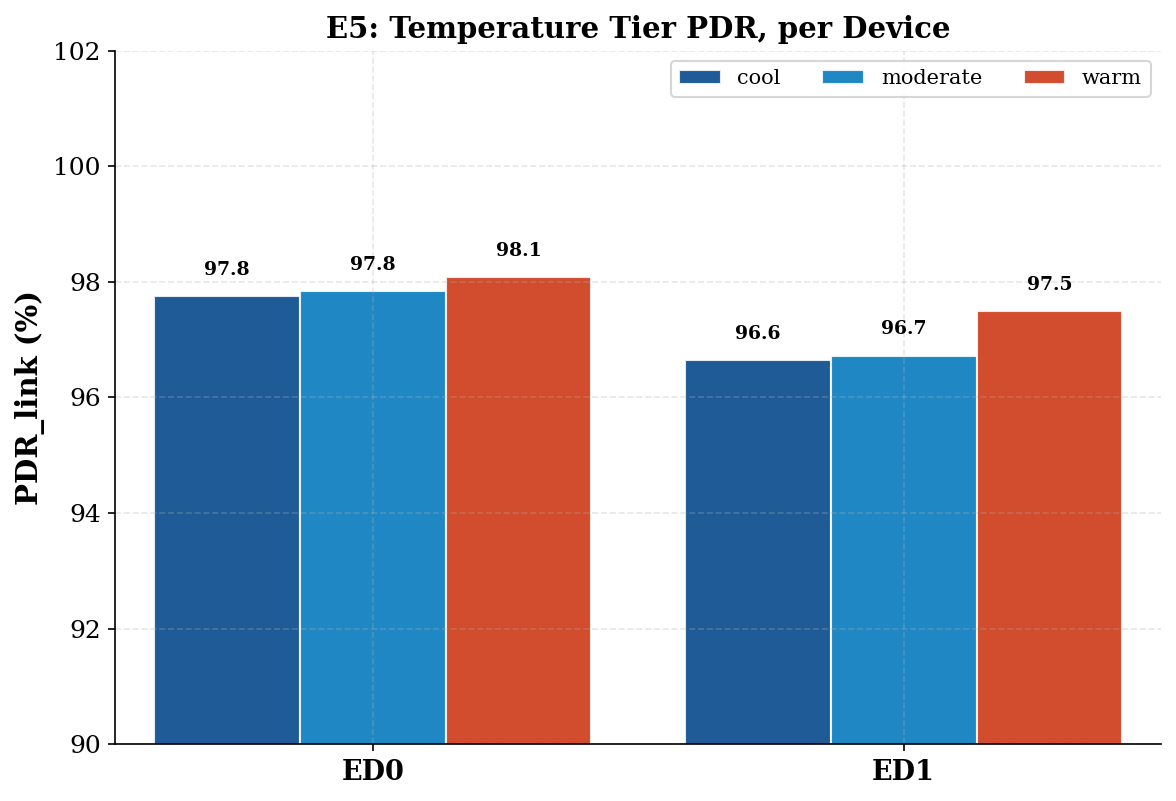

In [14]:
# Fig 04-D1 -- E5 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices5 = wide_e5_pdr.index.tolist()
cats5 = wide_e5_pdr.columns.tolist()
x0 = np.arange(len(devices5)) * 0.85
w0 = 0.7 / len(cats5)
colors5 = [C['navy'], C['blue'], C['red']]
for j, cat in enumerate(cats5):
    offset = (j - (len(cats5) - 1) / 2) * w0
    vals = wide_e5_pdr[cat].values
    ax.bar(x0 + offset, vals, w0, color=colors5[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x0 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x0)
ax.set_xticklabels(devices5, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E5: Temperature Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_d1_temperature_tier_pdr_per_device')

## 8 · Humidity Tier per Device (E6)

In [15]:
print('=' * 60)
print('E6: Humidity Tier PDR, per device')
print('=' * 60)
long_e6, wide_e6_pdr, wide_e6_n = per_device_pdr_table(
    'e6_humidity_tier', ['dry', 'normal', 'humid'])
print(wide_e6_pdr.round(2))
print('\nn per cell (humid tier is expected to be sparse and ED5-concentrated):')
print(wide_e6_n)

E6: Humidity Tier PDR, per device
category     dry  normal  humid
device_id                      
ED0        96.00   98.29    NaN
ED1        96.79   96.85    NaN

n per cell (humid tier is expected to be sparse and ED5-concentrated):
category     dry  normal  humid
device_id                      
ED0        77216  362870      0
ED1        66042  243691      0


  Saved: figures/4/04_d2_humidity_tier_pdr_per_device


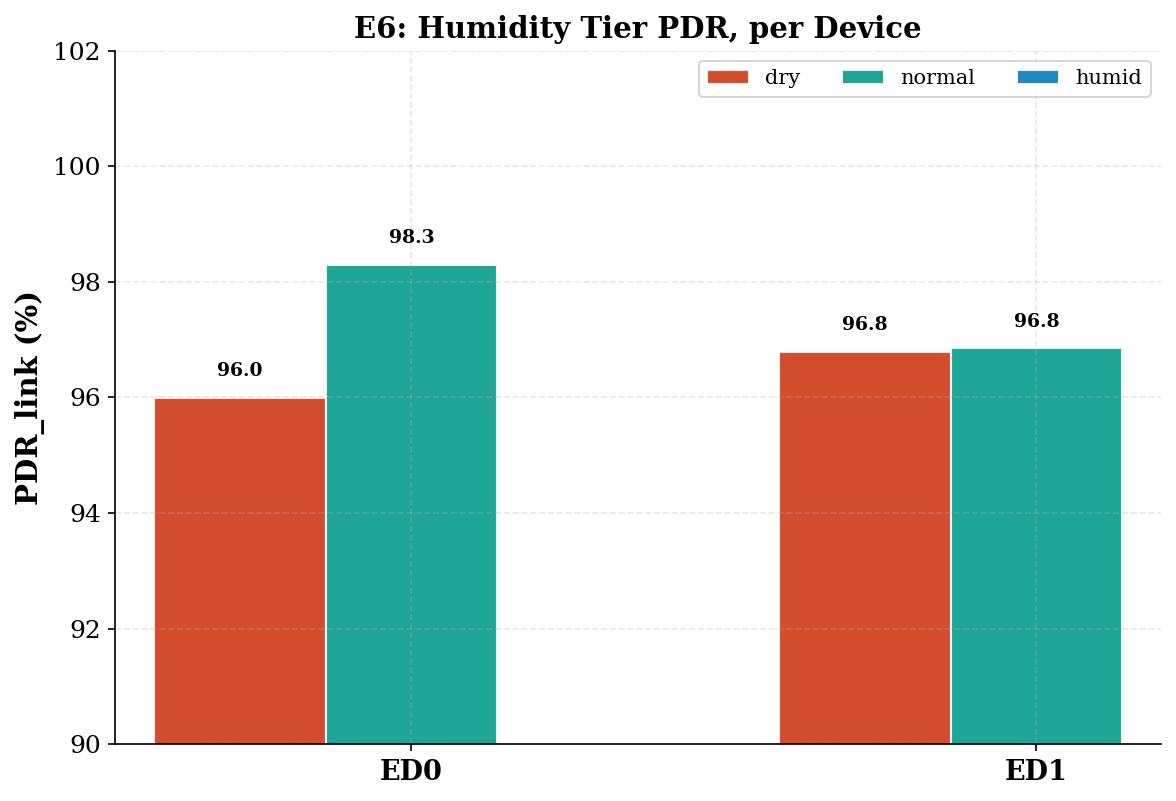

In [16]:
# Fig 04-D2 -- E6 per-device breakdown
fig, ax = plt.subplots(figsize=(8, 5.5))

devices6 = wide_e6_pdr.index.tolist()
cats6 = wide_e6_pdr.columns.tolist()
x1 = np.arange(len(devices6)) * 0.85
w1 = 0.7 / len(cats6)
colors6 = [C['red'], C['green'], C['blue']]
for j, cat in enumerate(cats6):
    offset = (j - (len(cats6) - 1) / 2) * w1
    vals = wide_e6_pdr[cat].values
    ax.bar(x1 + offset, vals, w1, color=colors6[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x1 + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
ax.set_xticks(x1)
ax.set_xticklabels(devices6, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=3)
ax.set_title('E6: Humidity Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_d2_humidity_tier_pdr_per_device')

## 9 · Spreading Factor per Device (E7)

In [17]:
print('=' * 60)
print('E7: PDR by Spreading Factor, per device')
print('=' * 60)
long_e7, wide_e7_pdr, wide_e7_n = per_device_pdr_table(
    'e7_sf', [7, 8, 9, 10, 11, 12])
wide_e7_pdr.columns = [f'SF{c}' for c in wide_e7_pdr.columns]
wide_e7_n.columns = [f'SF{c}' for c in wide_e7_n.columns]
print(wide_e7_pdr.round(2))
print('\nn per cell (recall SF11/SF12 were dropped from rotation on 4 Jul 2025):')
print(wide_e7_n)

E7: PDR by Spreading Factor, per device
             SF7    SF8    SF9   SF10   SF11   SF12
device_id                                          
ED0        98.78  98.55  97.76  97.84  96.24  96.80
ED1        98.29  97.70  96.68  96.17  95.73  95.83

n per cell (recall SF11/SF12 were dropped from rotation on 4 Jul 2025):
             SF7    SF8    SF9   SF10   SF11   SF12
device_id                                          
ED0        89584  89246  86828  83700  44947  45781
ED1        58916  58132  55359  51881  41954  43491


  Saved: figures/4/04_e_sf_pdr_per_device


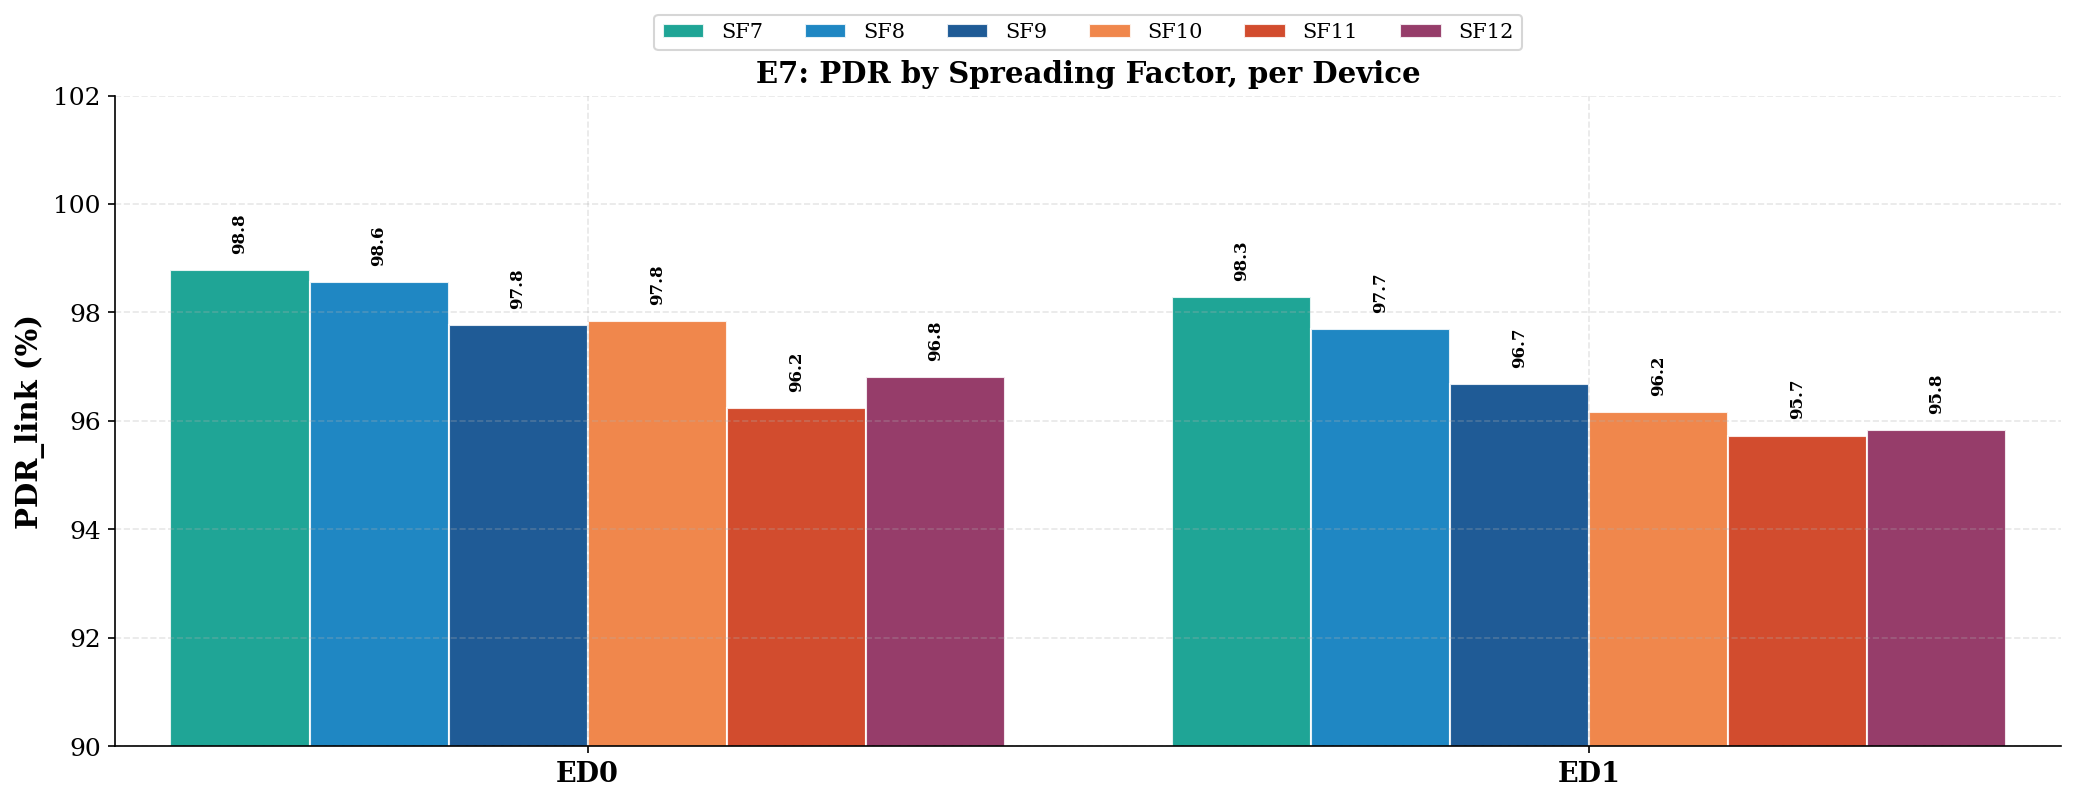

In [18]:
# Fig 04-E -- E7 per-device breakdown
devices7 = wide_e7_pdr.index.tolist()
cats7 = wide_e7_pdr.columns.tolist()
x = np.arange(len(devices7)) * 0.9
w = 0.75 / len(cats7)
colors7 = [C['green'], C['blue'], C['navy'], C['orange'], C['red'], C['brown']]

fig, ax = plt.subplots(figsize=(14, 5.5))
for j, cat in enumerate(cats7):
    offset = (j - (len(cats7) - 1) / 2) * w
    vals = wide_e7_pdr[cat].values
    ax.bar(x + offset, vals, w, color=colors7[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=8, fontweight='bold', rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(devices7, fontsize=13, fontweight='bold')
ax.margins(x=0.03)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=10, ncol=6, loc='upper center', bbox_to_anchor=(0.5, 1.14))
ax.set_title('E7: PDR by Spreading Factor, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(90, 102)

fig.tight_layout()
save_fig(fig, '04_e_sf_pdr_per_device')

## 10 · ESP Tier per Device (E8)

In [19]:
print('=' * 60)
print('E8: ESP Tier PDR, per device')
print('=' * 60)
long_e8, wide_e8_pdr, wide_e8_n = per_device_pdr_table(
    'e8_esp_tier', ['poor', 'moderate', 'strong'])
print(wide_e8_pdr.round(2))
print('\nn per cell:')
print(wide_e8_n)

E8: ESP Tier PDR, per device
category    poor  moderate  strong
device_id                         
ED0        97.06     97.40   97.99
ED1        96.11     94.28   97.03

n per cell:
category    poor  moderate  strong
device_id                         
ED0        49155      1614  389317
ED1        41980      7675  260078


  Saved: figures/4/04_f_esp_tier_pdr_per_device


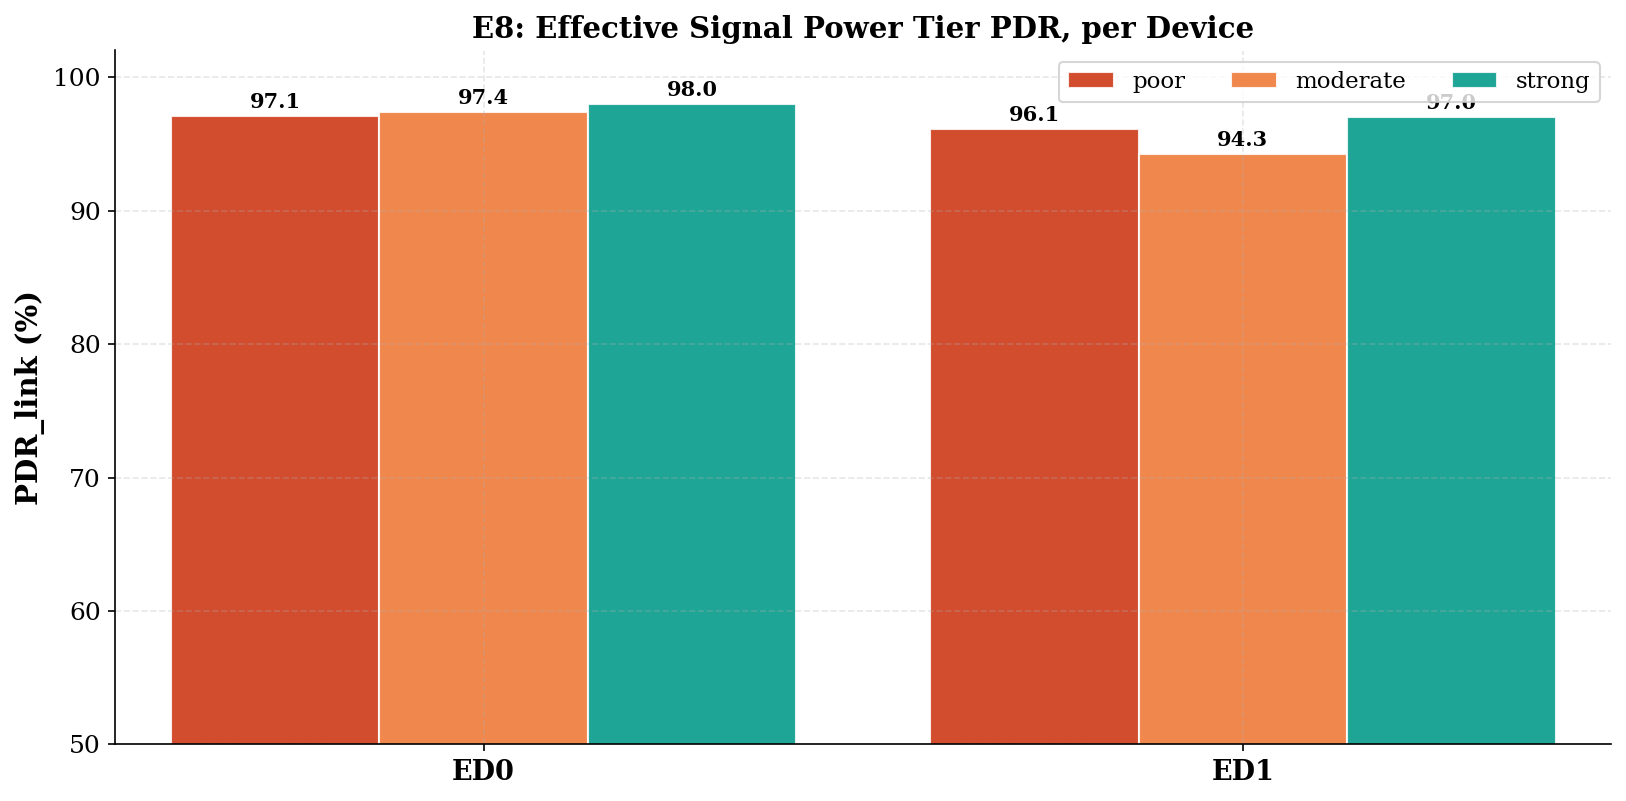

In [20]:
# Fig 04-F -- E8 per-device breakdown
devices8 = wide_e8_pdr.index.tolist()
cats8 = wide_e8_pdr.columns.tolist()
x = np.arange(len(devices8)) * 0.85
w = 0.7 / len(cats8)
colors8 = [C['red'], C['orange'], C['green']]

fig, ax = plt.subplots(figsize=(11, 5.5))
for j, cat in enumerate(cats8):
    offset = (j - (len(cats8) - 1) / 2) * w
    vals = wide_e8_pdr[cat].values
    ax.bar(x + offset, vals, w, color=colors8[j], alpha=0.88,
           edgecolor='white', label=cat)
    for xi, v in zip(x + offset, vals):
        if not np.isnan(v):
            ax.text(xi, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(devices8, fontsize=13, fontweight='bold')
ax.margins(x=0.04)
ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=11, ncol=3)
ax.set_title('E8: Effective Signal Power Tier PDR, per Device', fontsize=14, fontweight='bold')
ax.set_ylim(50, 102)

fig.tight_layout()
save_fig(fig, '04_f_esp_tier_pdr_per_device')

## 11 · Consistency Summary — Does the Pooled Effect Replicate in Every Device?

For each event's primary contrast (the same pairs reported in Notebook 03's summary table), this section compares the pooled PDR difference against the direction of the PDR difference computed independently within each device. "Consistent" means all six devices agree in direction with each other (not necessarily with the pooled result, though in practice a 6/6 agreement will match the pooled sign too, since the pooled figure is a weighted average of the six).

In [21]:
print('=' * 60)
print('CONSISTENCY SUMMARY -- pooled direction vs per-device direction')
print('=' * 60)

primary_contrasts = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E2', 'e2_co2_rising', 1, 0, 'CO2 rising vs stable'),
    ('E3', 'e3_office_hours', 1, 0, 'Office hours vs off-peak'),
    ('E4', 'e4_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E5', 'e5_temp_tier', 'warm', 'cool', 'Warm vs Cool'),
    ('E6', 'e6_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E7', 'e7_sf', 12, 7, 'SF12 vs SF7'),
    ('E8', 'e8_esp_tier', 'poor', 'strong', 'Poor vs Strong ESP'),
]

def pooled_pdr_compare(event_col, group1, group0=None):
    g1 = df_link[df_link[event_col] == group1]
    g0 = df_link[df_link[event_col] != group1] if group0 is None else df_link[df_link[event_col] == group0]
    return pdr_grp(g1) - pdr_grp(g0)

consistency_rows = []
per_device_detail = {}

for eid, col, g1, g0, label in primary_contrasts:
    dev_table = per_device_binary_compare(col, g1, g0, min_n=5)
    per_device_detail[eid] = dev_table

    valid = dev_table.dropna(subset=['diff_pp'])
    n_worse = int((valid['diff_pp'] < 0).sum())
    n_better = int((valid['diff_pp'] > 0).sum())
    n_valid = len(valid)

    pooled_diff = pooled_pdr_compare(col, g1, g0)
    pooled_dir = 'worse' if pooled_diff < 0 else 'better'
    consistent = (n_worse == n_valid) or (n_better == n_valid)

    consistency_rows.append({
        'Event': eid, 'Comparison': label,
        'Pooled_diff_pp': pooled_diff, 'Pooled_direction': pooled_dir,
        'Devices_worse': n_worse, 'Devices_better': n_better,
        'Devices_valid': n_valid, 'Consistent_across_devices': consistent,
    })

    print(f"\n{eid}: {label}")
    print(f"  Pooled            : {pooled_diff:+.2f} pp ({pooled_dir})")
    print(f"  Devices worse     : {n_worse}/{n_valid}")
    print(f"  Devices better    : {n_better}/{n_valid}")
    print(f"  {'-> CONSISTENT across devices' if consistent else '-> INCONSISTENT (device-dependent)'}")

consistency_df = pd.DataFrame(consistency_rows)
print('\n' + '=' * 60)
print(consistency_df.to_string(index=False))

CONSISTENCY SUMMARY -- pooled direction vs per-device direction

E1: High CO2 vs Background
  Pooled            : -2.76 pp (worse)
  Devices worse     : 2/2
  Devices better    : 0/2
  -> CONSISTENT across devices

E2: CO2 rising vs stable
  Pooled            : -32.59 pp (worse)
  Devices worse     : 2/2
  Devices better    : 0/2
  -> CONSISTENT across devices

E3: Office hours vs off-peak
  Pooled            : -1.23 pp (worse)
  Devices worse     : 2/2
  Devices better    : 0/2
  -> CONSISTENT across devices

E4: Elevated vs Clean PM2.5
  Pooled            : -21.63 pp (worse)
  Devices worse     : 2/2
  Devices better    : 0/2
  -> CONSISTENT across devices

E5: Warm vs Cool
  Pooled            : +0.64 pp (better)
  Devices worse     : 0/2
  Devices better    : 2/2
  -> CONSISTENT across devices

E6: Humid vs Dry
  Pooled            : -96.36 pp (worse)
  Devices worse     : 0/0
  Devices better    : 0/0
  -> CONSISTENT across devices

E7: SF12 vs SF7
  Pooled            : -2.26 pp (wo

  Saved: figures/4/04_g_consistency_summary


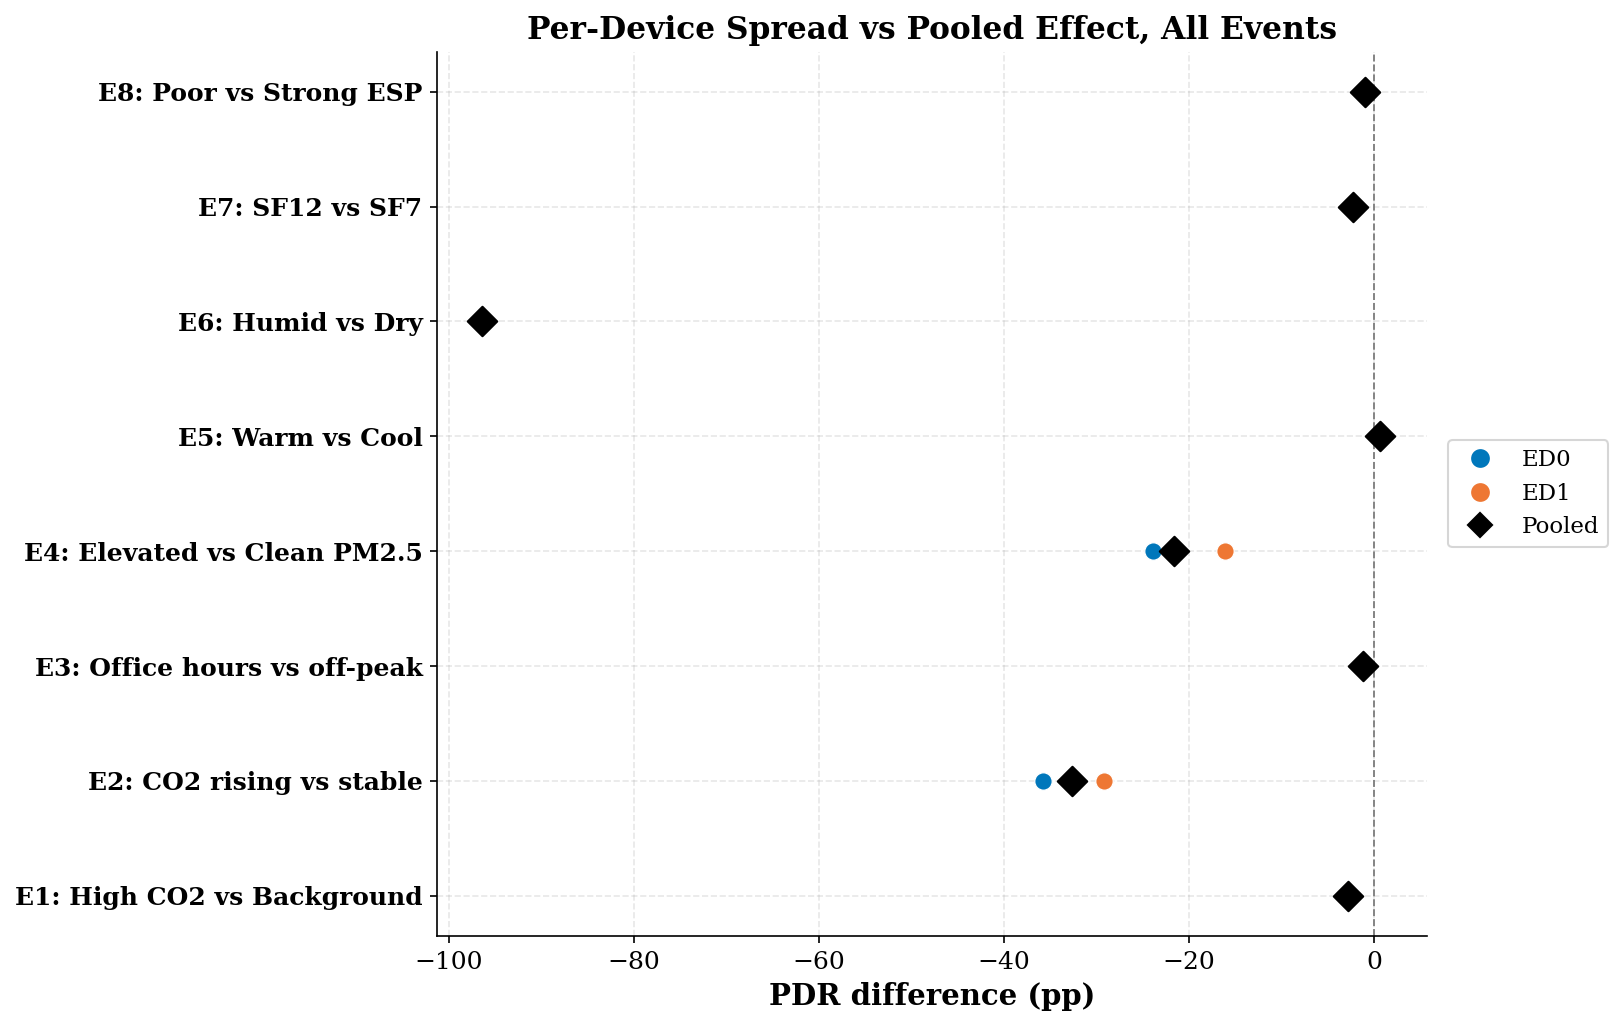

In [22]:
# Fig 04-G -- per-device spread vs pooled effect, all events
fig, ax = plt.subplots(figsize=(11, 7))

event_order = [row['Event'] for row in consistency_rows]
y_positions = {eid: i for i, eid in enumerate(event_order)}
devices_all = sorted(df_link['device_id'].unique())
device_color_map = dict(zip(devices_all, DEVICE_COLORS))

for eid, col, g1, g0, label in primary_contrasts:
    y = y_positions[eid]
    dev_table = per_device_detail[eid]
    for _, row in dev_table.dropna(subset=['diff_pp']).iterrows():
        ax.scatter(row['diff_pp'], y, color=device_color_map[row['device_id']],
                   s=70, zorder=3, edgecolor='white', linewidth=0.6)
    pooled_diff = pooled_pdr_compare(col, g1, g0)
    ax.scatter(pooled_diff, y, color='black', marker='D', s=100, zorder=4)

ax.axvline(x=0, color='grey', lw=0.9, ls='--')
ax.set_yticks(range(len(event_order)))
ax.set_yticklabels([f'{eid}: {label}' for eid, _, _, _, label in primary_contrasts],
                    fontsize=12, fontweight='bold')
ax.set_xlabel('PDR difference (pp)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.set_title('Per-Device Spread vs Pooled Effect, All Events', fontsize=15, fontweight='bold')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=device_color_map[d],
                       markersize=10, label=d) for d in devices_all]
handles.append(plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                           markersize=10, label='Pooled'))
ax.legend(handles=handles, fontsize=11, loc='center left', bbox_to_anchor=(1.01, 0.5))

fig.tight_layout()
save_fig(fig, '04_g_consistency_summary')

## 12 · Save Results

In [23]:
# per-device PDR tables for every event, long format, concatenated with an Event column
per_device_long_frames = []
event_tables = {
    'E1': (long_e1), 'E4': (long_e4), 'E5': (long_e5),
    'E6': (long_e6), 'E7': (long_e7), 'E8': (long_e8),
}
for eid, tbl in event_tables.items():
    t = tbl.copy()
    t.insert(0, 'Event', eid)
    per_device_long_frames.append(t)

# binary-comparison events are already tidy per-device tables
for eid, tbl in [('E2', e2_dev), ('E3', e3_dev)]:
    t = tbl.copy()
    t.insert(0, 'Event', eid)
    per_device_long_frames.append(t)

per_device_results = pd.concat(per_device_long_frames, ignore_index=True, sort=False)
per_device_results.to_csv(DATA_DIR / '4_per_device_results.csv', index=False)

consistency_df.to_csv(DATA_DIR / '4_consistency_summary.csv', index=False)

print(f'Saved: {DATA_DIR / "4_per_device_results.csv"}')
print(f'Saved: {DATA_DIR / "4_consistency_summary.csv"}')
print('\nNotebook 04 complete.')

Saved: ..\data\4_per_device_results.csv
Saved: ..\data\4_consistency_summary.csv

Notebook 04 complete.
